<a href="https://colab.research.google.com/github/shernandez-ucm/AI-MDS/blob/main/tutorial_opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial de Transformaciones de Imágenes con Python y OpenCV

Bienvenido a este tutorial sobre transformaciones geométricas de imágenes. Las transformaciones son operaciones fundamentales en visión por computadora que nos permiten modificar la orientación, el tamaño o la perspectiva de una imagen.

En este notebook, exploraremos las siguientes transformaciones utilizando la biblioteca OpenCV:

1.  **Cambio de Escala (Redimensionar)**
2.  **Traslación (Mover)**
3.  **Rotación**
4.  **Transformación Afín**
5.  **Transformación de Perspectiva**

Este tutorial se basa en la [documentación oficial de OpenCV](https://opencv-tutorial.readthedocs.io/en/latest/trans/transform.html#).

## 1. Configuración del Entorno

Primero, importaremos las bibliotecas necesarias. Necesitaremos `cv2` para las operaciones de imagen, `numpy` para manejar las matrices de transformación y `matplotlib` para mostrar las imágenes directamente en el notebook.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que matplotlib muestre las imágenes más grandes
plt.rcParams['figure.figsize'] = (8, 8)

In [2]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg

zsh:1: command not found: wget


In [6]:
! curl --output messi5.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 72937  100 72937    0     0   195k      0 --:--:-- --:--:-- --:--:--  195k


## 2. Cargar una Imagen de Ejemplo

Para este tutorial, usaremos una imagen de ejemplo. Puedes descargarla desde el repositorio de OpenCV o usar cualquier imagen tuya.

**Nota importante:** OpenCV carga las imágenes en formato BGR (Azul, Verde, Rojo), mientras que Matplotlib las muestra en formato RGB (Rojo, Verde, Azul). Por lo tanto, cuando mostremos una imagen a color, necesitaremos convertirla de BGR a RGB.

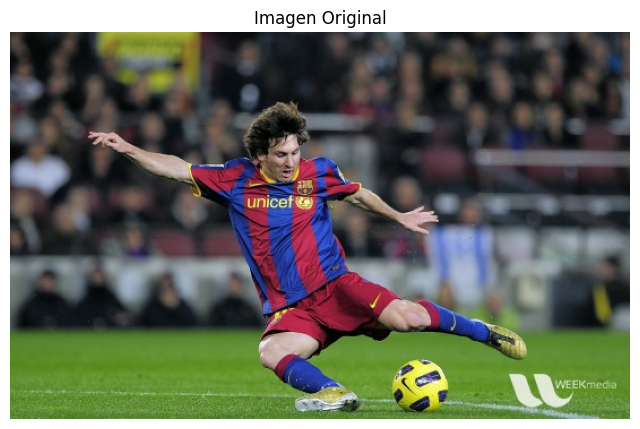

In [7]:
# Descarga la imagen de ejemplo si no la tienes:
# !wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg

# Cargar la imagen
img = cv2.imread('messi5.jpg')

# Convertir de BGR a RGB para mostrarla correctamente con Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar la imagen original
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off') # Ocultar ejes
plt.show()

## 3. Cambio de Escala (Redimensionar)

El cambio de escala se utiliza para modificar el tamaño (ancho y alto) de una imagen. OpenCV proporciona la función `cv2.resize()` para esto.

El tamaño final se puede especificar manualmente o usando un factor de escala. Además, podemos elegir diferentes **métodos de interpolación**:

-   `cv2.INTER_AREA`: Ideal para **reducir** el tamaño de la imagen.
-   `cv2.INTER_CUBIC`: De mayor calidad pero más lento, bueno para **ampliar**.
-   `cv2.INTER_LINEAR`: El método predeterminado, bueno para **ampliar** y con un buen balance de velocidad/calidad.

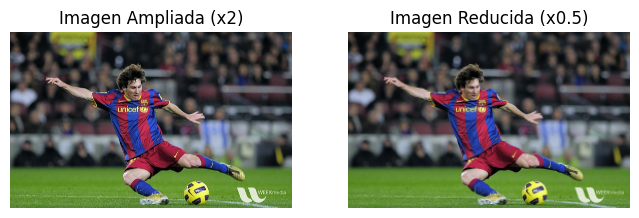

In [8]:
alto, ancho = img.shape[:2]

# Ejemplo 1: Ampliar la imagen al doble de su tamaño
img_ampliada = cv2.resize(img_rgb, None, fx=20, fy=20, interpolation=cv2.INTER_CUBIC)

# Ejemplo 2: Reducir la imagen a la mitad de su tamaño
img_reducida = cv2.resize(img_rgb, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

# Mostrar los resultados
plt.subplot(1, 2, 1)
plt.imshow(img_ampliada)
plt.title('Imagen Ampliada (x2)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_reducida)
plt.title('Imagen Reducida (x0.5)')
plt.axis('off')

plt.show()

## 4. Traslación (Mover una Imagen)

La traslación consiste en mover la ubicación de un objeto en la imagen. Para ello, creamos una **matriz de transformación `M`** de 2x3.

$$ M = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix} $$

Donde $t_x$ es el desplazamiento en el eje X y $t_y$ es el desplazamiento en el eje Y. Luego, aplicamos esta matriz usando la función `cv2.warpAffine()`.

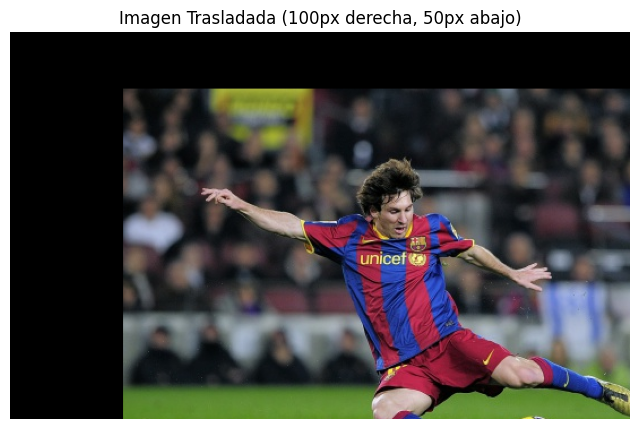

In [9]:
alto, ancho = img.shape[:2]

# Crear la matriz de traslación para mover 100 píxeles a la derecha y 50 hacia abajo
M_traslacion = np.float32([[1, 0, 100], [0, 1, 50]])

# Aplicar la traslación
# El tercer parámetro es el tamaño de la imagen de salida (ancho, alto)
img_trasladada = cv2.warpAffine(img_rgb, M_traslacion, (ancho, alto))

# Mostrar resultado
plt.imshow(img_trasladada)
plt.title('Imagen Trasladada (100px derecha, 50px abajo)')
plt.axis('off')
plt.show()

## 5. Rotación

Para rotar una imagen, necesitamos definir un punto central de rotación, un ángulo y un factor de escala opcional. OpenCV simplifica esto con la función `cv2.getRotationMatrix2D()` que genera la matriz de transformación por nosotros.

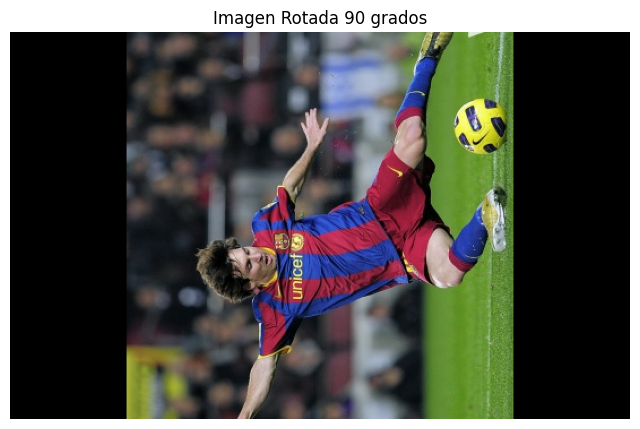

In [10]:
alto, ancho = img.shape[:2]

# Obtener la matriz de rotación
# Parámetros: centro (ancho/2, alto/2), ángulo en grados, escala
M_rotacion = cv2.getRotationMatrix2D((ancho/2, alto/2), 90, 1)

# Aplicar la rotación
img_rotada = cv2.warpAffine(img_rgb, M_rotacion, (ancho, alto))

# Mostrar resultado
plt.imshow(img_rotada)
plt.title('Imagen Rotada 90 grados')
plt.axis('off')
plt.show()

## 6. Transformación Afín

Una transformación afín es una transformación geométrica que conserva las líneas y el paralelismo (las líneas paralelas siguen siendo paralelas). La traslación, la rotación y el escalado son tipos de transformaciones afines.

Para encontrar la matriz de transformación, necesitamos definir **tres puntos** en la imagen de entrada y sus correspondientes ubicaciones en la imagen de salida. OpenCV calculará la matriz adecuada con `cv2.getAffineTransform()`.

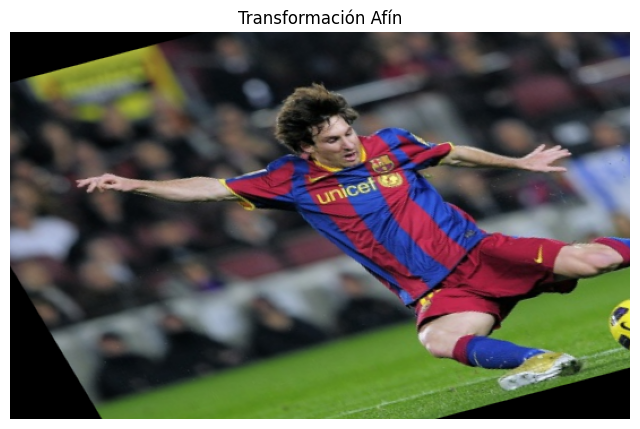

In [12]:
alto, ancho = img_rgb.shape[:2]

# Puntos de origen en la imagen original
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])

# Puntos de destino en la imagen de salida
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

# Obtener la matriz de transformación afín
M_afin = cv2.getAffineTransform(pts1, pts2)

# Aplicar la transformación
img_afin = cv2.warpAffine(img_rgb, M_afin, (ancho, alto))

# Mostrar resultado
plt.imshow(img_afin)
plt.title('Transformación Afín')
plt.axis('off')
plt.show()

## 7. Transformación de Perspectiva

Para una transformación de perspectiva, necesitamos una matriz de 3x3. Las líneas rectas permanecerán rectas, pero las líneas paralelas podrían converger. Este tipo de transformación es muy útil para obtener una vista "aérea" o frontal de un objeto que fue fotografiado desde un ángulo.

Para encontrar la matriz, necesitamos **cuatro puntos** en el plano de entrada y sus correspondientes en el plano de salida. Usamos `cv2.getPerspectiveTransform()`.

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  244k  100  244k    0     0   639k      0 --:--:-- --:--:-- --:--:--  640k
Download complete.


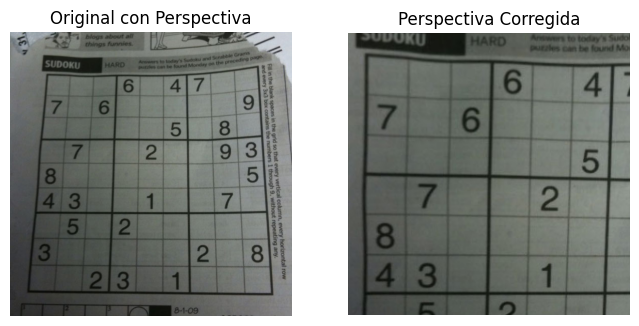

In [13]:
import os

# Define the image file name
sudoku_image_file = 'sudoku.png'

# Download the image if it doesn't exist
if not os.path.exists(sudoku_image_file):
  print(f"Downloading {sudoku_image_file}...")
  #! curl --output messi5.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg"
  ! curl --output sudoku.png "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png"
  print("Download complete.")

# Cargar la imagen
img_sudoku = cv2.imread(sudoku_image_file)

# Check if the image was loaded successfully
if img_sudoku is None:
    print(f"Error loading image: {sudoku_image_file}")
else:
    img_sudoku_rgb = cv2.cvtColor(img_sudoku, cv2.COLOR_BGR2RGB)
    alto, ancho = img_sudoku_rgb.shape[:2]

    # Puntos de origen (las 4 esquinas del sudoku en la imagen original)
    pts1_perspectiva = np.float32([[56, 65], [368, 52], [28, 387], [389, 390]])

    # Puntos de destino (las 4 esquinas de la imagen de salida, formando un rectángulo)
    pts2_perspectiva = np.float32([[0, 0], [300, 0], [0, 300], [300, 300]])

    # Obtener la matriz de transformación de perspectiva
    M_perspectiva = cv2.getPerspectiveTransform(pts1_perspectiva, pts2_perspectiva)

    # Aplicar la transformación
    img_perspectiva = cv2.warpPerspective(img_sudoku_rgb, M_perspectiva, (300, 300))

    # Mostrar los resultados
    plt.subplot(1, 2, 1)
    plt.imshow(img_sudoku_rgb)
    plt.title('Original con Perspectiva')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_perspectiva)
    plt.title('Perspectiva Corregida')
    plt.axis('off')

    plt.show()

# Tareas

---

### **Tarea 1: Conversión de Espacios de Color**
*   **BGR vs RGB:** Recuerda siempre que OpenCV carga imágenes en formato **BGR** (Azul, Verde, Rojo). Si usas `matplotlib` para mostrar imágenes, necesitarás convertirlas a **RGB**.

**Descripción:**
1.  Busca una imagen en tu computadora (o descarga una de internet) y guárdala en la misma carpeta que tu script de Python.
2.  Escribe un script que cargue la imagen usando OpenCV.
3.  Imprime en la consola el alto, el ancho y el número de canales de la imagen.
4.  Convierte la imagen a escala de grises.
5.  Muestra tanto la imagen original como la imagen en escala de grises en dos ventanas separadas.
6.  Guarda la imagen en escala de grises en tu disco con un nuevo nombre (ej. `mi_imagen_gris.jpg`).

**Pistas y Funciones Clave:**
*   `cv2.imread('nombre_de_tu_imagen.jpg')`
*   `imagen.shape` (devuelve una tupla `(alto, ancho, canales)`)
*   `cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)`
*   `cv2.imshow('Titulo de la Ventana', imagen)`
*   `cv2.waitKey(0)` (esencial para que las ventanas no se cierren al instante)
*   `cv2.destroyAllWindows()`
*   `cv2.imwrite('nuevo_nombre.jpg', imagen_gris)`

**Desafío Adicional (Opcional):**
En lugar de una imagen, abre la cámara web de tu computadora, muestra el video en tiempo real y conviértelo a escala de grises en cada fotograma. Cierra el programa cuando el usuario presione la tecla 'q'.

* Pista: Usa cv2.VideoCapture(0) y un bucle while True:.






### **Tarea 2: Segmentación por Color**

**Objetivos de Aprendizaje:**
*   Comprender y utilizar el espacio de color HSV.
*   Crear una máscara para aislar un color específico.
*   Aplicar la máscara para segmentar un objeto de la imagen.

**Descripción:**
1.  Encuentra o toma una foto de un objeto con un color muy distintivo (ej. un limón sobre una mesa, una tapa de botella azul).
2.  Carga la imagen y conviértela del espacio BGR al espacio de color **HSV**.
3.  Utiliza un histograma para determinar los valores H,S y V que corresponden al objeto. H representa al color (0-180) y S la luminancia (0-255)
3.  Define el rango de valores de H, S y V que corresponden al color de tu objeto.
4.  Crea una máscara que sea blanca donde los píxeles caen dentro de tu rango de color y negra en el resto, usando `cv2.inRange()`.
5.  Utiliza la máscara para "recortar" el objeto de la imagen original. El resultado debe ser una imagen que solo muestre el objeto coloreado y el resto en negro.
6.  Muestra la imagen original, la máscara y el resultado final.

**Pistas y Funciones Clave:**
*   `cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)`
*   `hist = cv.calcHist([imagen_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])`
*   `limite_inferior = np.array([H_min, S_min, V_min])`
*   `limite_superior = np.array([H_max, S_max, V_max])`
*   `cv2.inRange(imagen_hsv, limite_inferior, limite_superior)`
*   `cv2.bitwise_and(imagen_original, imagen_original, mask=mascara)`


### **Tarea 3 Detección de Rostros**

**Objetivos de Aprendizaje:**
*   Utilizar un clasificador pre-entrenado (Haar Cascade).
*   Detectar objetos (en este caso, rostros) en una imagen o video.
*   Dibujar rectángulos (bounding boxes) alrededor de los objetos detectados.

**Descripción:**
1.  Descarga el archivo `haarcascade_frontalface_default.xml` del [repositorio de OpenCV](https://github.com/opencv/opencv/tree/master/data/haarcascades).
2.  Carga el clasificador Haar Cascade usando OpenCV.
3.  Carga una imagen que contenga uno o más rostros.
4.  Convierte la imagen a escala de grises (los clasificadores Haar funcionan mejor en escala de grises).
5.  Utiliza el método `detectMultiScale` del clasificador para obtener una lista de rectángulos que contienen los rostros detectados.
6.  Recorre la lista de rostros y dibuja un rectángulo verde alrededor de cada uno en la **imagen original a color**.
7.  Muestra la imagen final con los rostros detectados.

**Pistas y Funciones Clave:**
*   `cv2.CascadeClassifier('haarcascade_frontalface_default.xml')`
*   `clasificador.detectMultiScale(imagen_gris, scaleFactor=1.1, minNeighbors=5)`
*   El método devuelve una lista de `(x, y, ancho, alto)` para cada rostro.
*   Usa `cv2.rectangle()` para dibujar los cuadros.
